In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-08-01-01-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-02-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-02-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-06-02-02-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-04-01-02-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-02-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-03-01-01-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-01-02-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-05-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_0

In [2]:
import os
import pandas as pd
import numpy as np
import librosa
from pydub import AudioSegment, effects
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [4]:
REVDESS = "/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/"
TESS = "/kaggle/input/toronto-emotional-speech-set-tess/tess toronto emotional speech set data/TESS Toronto emotional speech set data/"

In [5]:
ravdess_dir_list = os.listdir(REVDESS)
path_list = []
gender_list = []
emotion_list = []

emotion_dic = {
    '03': 'happy',
    '01': 'neutral',
    '04': 'sad',
    '05': 'angry',
#     '02':'calm,
    '06':'fearful',
    '07':'disgust',
    '08':'surprised'
}
for directory in ravdess_dir_list:
    actor_files = os.listdir(os.path.join(REVDESS, directory))
    for audio_file in actor_files:
        part = audio_file.split('.')[0]
        key = part.split('-')[2]
        if key in emotion_dic:
            gender_code = int(part.split('-')[6])
            path_list.append(f"{REVDESS}{directory}/{audio_file}")
            gender_list.append('female' if gender_code & 1 == 0 else 'male')
            emotion_list.append(emotion_dic[key])

revdess_df = pd.concat([
    pd.DataFrame(path_list, columns=['path']),
    pd.DataFrame(gender_list, columns=['sex']),
    pd.DataFrame(emotion_list, columns=['emotion'])
], axis=1)

In [6]:
tess_dir_list = os.listdir(TESS)
path_list = []
gender_list = []
emotion_list = []

emotion_dic = {
    'happy': 'happy',
    'neutral': 'neutral',
    'sad': 'sad',
    'angry': 'angry',
    'disgust':'disgust',
    'fear':'fearful',
    'pleasant_surprise':'surprised'
}

for directory in tess_dir_list:
    audio_files = os.listdir(os.path.join(TESS, directory))
    for audio_file in audio_files:
        part = audio_file.split('.')[0]
        key = part.split('_')[2]
        if key in emotion_dic:
            path_list.append(f"{TESS}{directory}/{audio_file}")
            gender_list.append('female')  # female only dataset
            emotion_list.append(emotion_dic[key])

tess_df = pd.concat([
    pd.DataFrame(path_list, columns=['path']),
    pd.DataFrame(gender_list, columns=['sex']),
    pd.DataFrame(emotion_list, columns=['emotion'])
], axis=1)


In [7]:
print(revdess_df.columns)
print(tess_df.columns)

Index(['path', 'sex', 'emotion'], dtype='object')
Index(['path', 'sex', 'emotion'], dtype='object')


In [8]:
revdess_df = revdess_df.reset_index(drop=True)
tess_df = tess_df.reset_index(drop=True)
df = pd.concat([revdess_df, tess_df], axis=0).reset_index(drop=True)
print(revdess_df.shape)
print(tess_df.shape)
df = pd.concat([revdess_df, tess_df], axis=0, ignore_index=True)
print(df.columns)


(1248, 3)
(2400, 3)
Index(['path', 'sex', 'emotion'], dtype='object')


In [9]:
print(df.columns)


Index(['path', 'sex', 'emotion'], dtype='object')


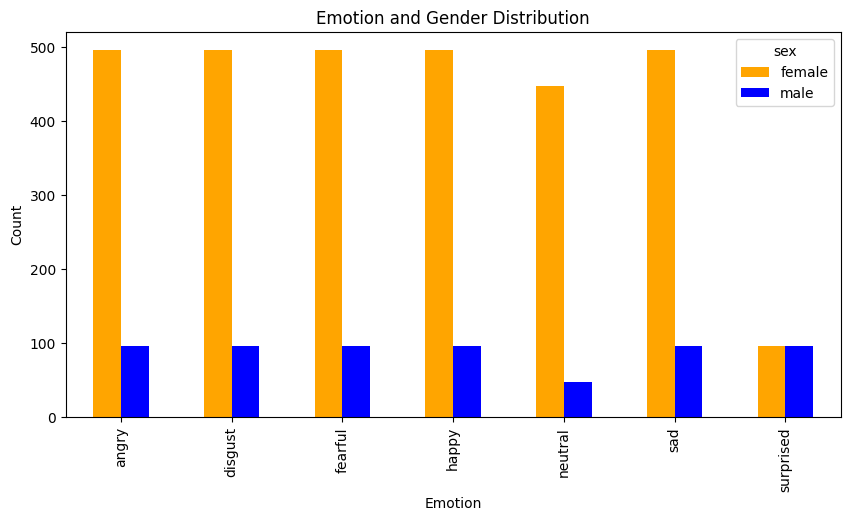

In [10]:
import matplotlib.pyplot as plt

def plot_distribution(df): 
    count_table = df.groupby(['emotion', 'sex']).count()
    pivot_table = count_table.pivot_table(index='emotion', columns='sex', values='path')

    pivot_table.plot(kind='bar', figsize=(10, 5), color=['orange', 'blue'])
    plt.title('Emotion and Gender Distribution')
    plt.xlabel('Emotion')
    plt.ylabel('Count')

    # Save the plot as a PNG file
    plt.savefig('/kaggle/working/emotion_gender_distribution.png')
    
    # Display the plot
    plt.show()

# Assuming df is your DataFrame
plot_distribution(df)

# Drop the 'sex' column
df.drop('sex', axis=1, inplace=True)

# Encoding the labels
emotion_dic = {
    'neutral': 0,
    'happy': 1,
    'sad': 2,
    'angry': 3,
    'disgust':4,
    'fearful':5,
    'surprised':6
}
df['emotion'] = df['emotion'].map(emotion_dic)


In [11]:
from pydub import AudioSegment, effects

def preprocess_audio(path):
    _, sr = librosa.load(path)
    raw_audio = AudioSegment.from_file(path)
    
    samples = np.array(raw_audio.get_array_of_samples(), dtype='float32')
    trimmed, _ = librosa.effects.trim(samples, top_db=25)
    padded = np.pad(trimmed, (0, 180000 - len(trimmed)), 'constant')
    return padded, sr

In [12]:
X = []
y = []

for row in df.itertuples(index=False):
    try:
        audio, _ = preprocess_audio(row.path)
        X.append(audio)
        y.append(row.emotion)
    except:
        print(f"Failed for path: {row.path}")

X = np.array(X)
y = np.array(y)

# Extract features
zcr_list = []
rms_list = []
mfccs_list = []

FRAME_LENGTH = 2048
HOP_LENGTH = 512

for audio in X:
    zcr = librosa.feature.zero_crossing_rate(audio, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)
    rms = librosa.feature.rms(y=audio, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)
    mfccs = librosa.feature.mfcc(y=audio, sr=44100, n_mfcc=13, hop_length=HOP_LENGTH)

    zcr_list.append(zcr)
    rms_list.append(rms)
    mfccs_list.append(mfccs)

X_features = np.concatenate((
    np.swapaxes(zcr_list, 1, 2),
    np.swapaxes(rms_list, 1, 2),
    np.swapaxes(mfccs_list, 1, 2)),
    axis=2
)

Failed for path: /kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/Actor_20/03-01-06-01-01-02-20.wav


In [ ]:
print(zcr_list , rms_list , mfccs_list)

In [13]:
from keras.models import Sequential
from keras import layers, callbacks

X_train, X_to_split, y_train, y_to_split = train_test_split(X_features, y, test_size=0.3, random_state=1)
X_val, X_test, y_val, y_test = train_test_split(X_to_split, y_to_split, test_size=0.3, random_state=1)


In [14]:

y_train_class = to_categorical(y_train, 7)
y_val_class = to_categorical(y_val, 7)

In [15]:
model = Sequential()
model.add(layers.LSTM(64, return_sequences=True, input_shape=(X_features.shape[1:3])))
model.add(layers.LSTM(64))
model.add(layers.Dense(7, activation='softmax'))

/opt/conda/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 352, 64)        │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,959 (210.78 KB)

 Trainable params: 53,959 (210.78 KB)

 Non-trainable params: 0 (0.00 B)

None


In [17]:
model.compile(loss='categorical_crossentropy', optimizer='RMSProp', metrics=['accuracy'])
history = model.fit(X_train, y_train_class, epochs=50, batch_size=6, validation_data=(X_val, y_val_class))


Epoch 1/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 117s 268ms/step - accuracy: 0.2467 - loss: 1.7816 - val_accuracy: 0.3172 - val_loss: 1.6815
Epoch 2/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 115s 270ms/step - accuracy: 0.3743 - loss: 1.5861 - val_accuracy: 0.3564 - val_loss: 1.6397
Epoch 3/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 116s 272ms/step - accuracy: 0.4177 - loss: 1.4874 - val_accuracy: 0.3930 - val_loss: 1.5432
Epoch 4/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 115s 271ms/step - accuracy: 0.4352 - loss: 1.4185 - val_accuracy: 0.3969 - val_loss: 1.5750
Epoch 5/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 115s 270ms/step - accuracy: 0.4977 - loss: 1.3137 - val_accuracy: 0.4504 - val_loss: 1.3642
Epoch 6/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 114s 267ms/step - accuracy: 0.4887 - loss: 1.2857 - val_accuracy: 0.5065 - val_loss: 1.3066
Epoch 7/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 116s 272ms/step - accuracy: 0.5344 - loss: 1.2141 - val_accuracy: 0.4804 - val_loss: 1.2843
Epoch 8/50
426/426 ━━━━━━━━━━━━━━━━━━━━ 148s 285ms/step - accuracy: 0.5580 -

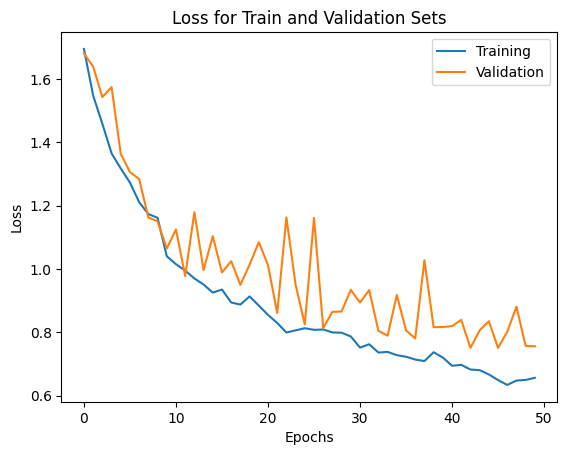

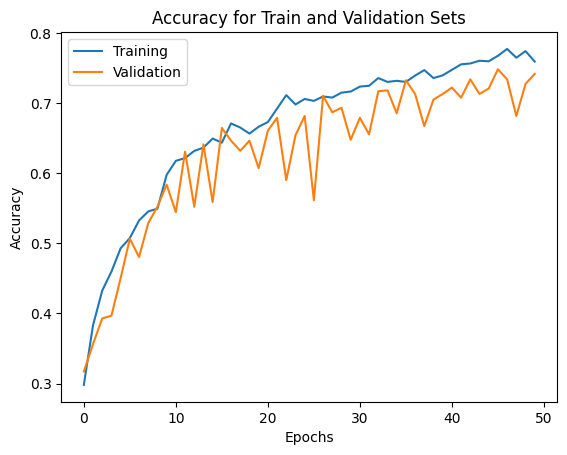

In [18]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss for Train and Validation Sets')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['Training', 'Validation'])
plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy for Train and Validation Sets')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['Training', 'Validation'])
plt.show()

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step


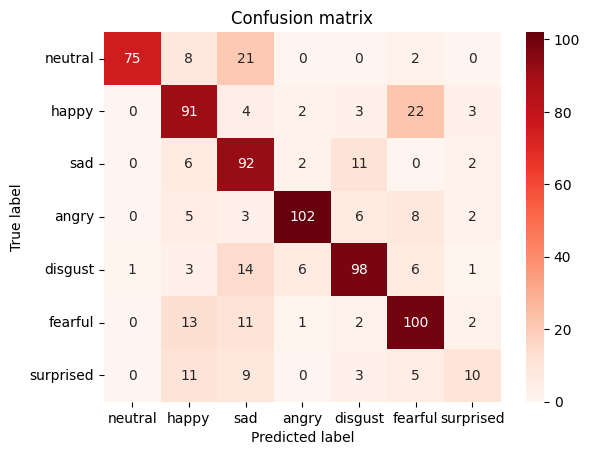

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = np.argmax(model.predict(X_val), axis=1)
labels = ['neutral', 'happy', 'sad', 'angry','disgust','fearful','surprised']
cm = confusion_matrix(y_val, y_pred, labels=range(7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion matrix')
plt.show()

In [21]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, to_categorical(y_test, 7))
print(f"Test Accuracy: {test_accuracy}")


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 0.7170 - loss: 0.8130
Test Accuracy: 0.7234042286872864


In [24]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
# Corrected dictionary
emotion_dic = {
    'neutral': 'neutral',
    'happy': 'happy',
    'sad': 'sad',       # Fixed typo here
    'angry': 'angry',
    'disgust': 'disgust',
    'fearful': 'fearful',
    'surprised': 'surprised'
}

# Convert the dictionary to a DataFrame
df_emotions = pd.DataFrame.from_dict(emotion_dic, orient='index', columns=['OLabel'])

# Reset index if you want 'Emotion' as a column
df_emotions = df_emotions.reset_index().rename(columns={'index': 'IEmotion'})

print(df_emotions)


if 'emotion' in df.columns:
    # Convert `emotion` column to a numpy array with shape (-1, 1)
    table = np.array(df['emotion'].astype(int)).reshape(-1, 1)

    # Initialize the encoder
    encoder = OneHotEncoder()

    # Fit and transform the data
    Y = encoder.fit_transform(table).toarray()

    print(Y.shape)  # Print the shape of the encoded array
else:
    print("The column 'emotion' does not exist in the dataframe.")

    IEmotion     OLabel
0    neutral    neutral
1      happy      happy
2        sad        sad
3      angry      angry
4    disgust    disgust
5    fearful    fearful
6  surprised  surprised
(3648, 7)


In [25]:
import numpy as np
import pandas as pd

# Step 1: Get model predictions
pred_test0 = model.predict(X_test)

# Step 2: Convert to class indices if `pred_test0` is not already one-dimensional
if pred_test0.ndim > 1 and pred_test0.shape[1] > 1:  # If pred_test0 has more than one column (probabilities)
    pred_test0 = np.argmax(pred_test0, axis=1)  # Convert to class indices

# Step 3: Check y_test shape, convert to class indices if one-hot encoded
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_test_indices = np.argmax(y_test, axis=1)
else:
    y_test_indices = y_test  # If already class indices

# Step 4: Convert class indices to one-hot encoded format
pred_test0_one_hot = np.eye(7)[pred_test0]
y_test0_one_hot = np.eye(7)[y_test_indices]

# Step 5: Use inverse_transform to get original labels
y_pred0 = encoder.inverse_transform(pred_test0_one_hot)
y_test0 = encoder.inverse_transform(y_test0_one_hot)

# Step 6: Create DataFrame for comparison
df0 = pd.DataFrame({
    'Predicted Labels': y_pred0.flatten(),
    'Actual Labels': y_test0.flatten()
})

print(df0.head())  # Display the first few rows


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step
   Predicted Labels  Actual Labels
0                 1              1
1                 2              2
2                 2              6
3                 4              4
4                 2              2


In [26]:
import numpy as np
import pandas as pd

# Define the emotion dictionary for mapping
emotion_dic = {
    0: 'neutral',
    1: 'happy',
    2: 'sad',
    3: 'angry',
    4: 'disgust',
    5: 'fearful',
    6: 'surprised'
}

# Step 1: Get model predictions
pred_test0 = model.predict(X_test)

# Step 2: Convert to class indices if `pred_test0` is not already one-dimensional
if pred_test0.ndim > 1 and pred_test0.shape[1] > 1:  # If pred_test0 has more than one column (probabilities)
    pred_test0 = np.argmax(pred_test0, axis=1)  # Convert to class indices

# Step 3: Check y_test shape, convert to class indices if one-hot encoded
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_test_indices = np.argmax(y_test, axis=1)
else:
    y_test_indices = y_test  # If already class indices

# Step 4: Use the emotion dictionary to map indices to emotion names
y_pred0_emotions = [emotion_dic[i] for i in pred_test0]
y_test0_emotions = [emotion_dic[i] for i in y_test_indices]

# Step 5: Create DataFrame for comparison
df0 = pd.DataFrame({
    'Predicted Labels': y_pred0_emotions,
    'Actual Labels': y_test0_emotions
})

print(df0)  # Display the first few rows


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step
    Predicted Labels Actual Labels
0              happy         happy
1                sad           sad
2                sad     surprised
3            disgust       disgust
4                sad           sad
..               ...           ...
324          disgust           sad
325            happy         happy
326          neutral       neutral
327          neutral       neutral
328        surprised       fearful

[329 rows x 2 columns]


In [29]:
from sklearn.metrics import classification_report
print(classification_report(y_test0_emotions, y_pred0_emotions))

              precision    recall  f1-score   support

       angry       0.76      0.88      0.81        57
     disgust       0.82      0.78      0.80        60
     fearful       0.67      0.75      0.70        51
       happy       0.71      0.60      0.65        50
     neutral       1.00      0.79      0.88        33
         sad       0.63      0.79      0.70        56
   surprised       0.27      0.14      0.18        22

    accuracy                           0.72       329
   macro avg       0.69      0.67      0.68       329
weighted avg       0.72      0.72      0.72       329



In [28]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

f1 = f1_score(y_test0_emotions, y_pred0_emotions, average='weighted')
precision = precision_score(y_test0_emotions, y_pred0_emotions, average='weighted')
recall = recall_score(y_test0_emotions, y_pred0_emotions, average='weighted')
accuracy = accuracy_score(y_test0_emotions, y_pred0_emotions)

# Print the metrics
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")

F1 Score: 0.7150
Precision: 0.7191
Recall: 0.7234
Accuracy: 0.7234


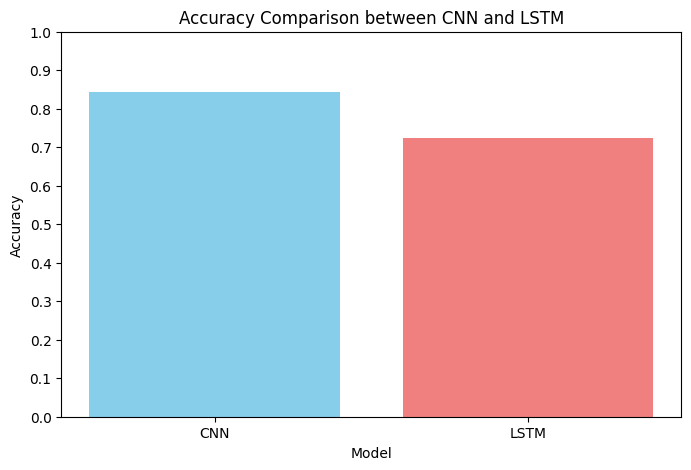

In [30]:
import matplotlib.pyplot as plt

# Data
models = ['CNN', 'LSTM']
accuracies = [0.8437, 0.7234]

# Plotting
plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['skyblue', 'lightcoral'])
plt.ylim(0, 1)  # Set y-axis limit to 0-1 for easier interpretation of accuracy

# Labels and Title
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison between CNN and LSTM")
plt.xticks(models)
plt.yticks([i * 0.1 for i in range(0, 11)])  # Add more detailed y-axis ticks

# Show the plot
plt.show()
